In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

from src.damage_models import delamination_area, residual_strength, predict_strength_from_energy
from src.generate_data import TRUE   # the hidden true values, used only to check our fits

df = pd.read_csv("../data/synthetic_cfrp.csv")
df.head()

,impact_energy_J,delam_area_mm2,CAI_strength_MPa,data_type
0,0.0,0.0,458.9,synthetic
1,0.0,0.0,456.5,synthetic
2,0.0,0.0,442.0,synthetic
3,0.0,0.0,452.8,synthetic
4,3.0,0.0,451.4,synthetic


In [2]:
print(df.describe())
print("Missing values:", df.isna().sum().sum())

       impact_energy_J  delam_area_mm2  CAI_strength_MPa
count        40.000000       40.000000         40.000000
mean         16.100000      297.017500        322.810000
std          12.232366      284.868435         93.447119
min           0.000000        0.000000        204.700000
25%           6.000000       26.425000        232.775000
50%          14.000000      223.350000        300.500000
75%          25.000000      520.825000        429.975000
max          40.000000      931.900000        460.500000
Missing values: 0


In [3]:
E = df["impact_energy_J"].values
A = df["delam_area_mm2"].values
S = df["CAI_strength_MPa"].values

In [4]:
def report(names, popt, pcov, n, true=None):
    """Print fitted values with 95% confidence intervals."""
    perr = np.sqrt(np.diag(pcov))
    tcrit = stats.t.ppf(0.975, n - len(popt))
    for i, name in enumerate(names):
        lo, hi = popt[i] - tcrit * perr[i], popt[i] + tcrit * perr[i]
        line = f"{name:7s} = {popt[i]:9.4f}   95% CI [{lo:9.4f}, {hi:9.4f}]"
        if true is not None:
            line += f"   true = {true[name]}   recovered: {lo <= true[name] <= hi}"
        print(line)

popt_area, pcov_area = curve_fit(delamination_area, E, A, p0=[4.0, 20.0])
report(["E_th", "c"], popt_area, pcov_area, len(E), TRUE)

E_th    =    4.6998   95% CI [   3.8940,    5.5056]   true = 5.0   recovered: True
c       =   24.6689   95% CI [  23.5935,   25.7443]   true = 25.0   recovered: True


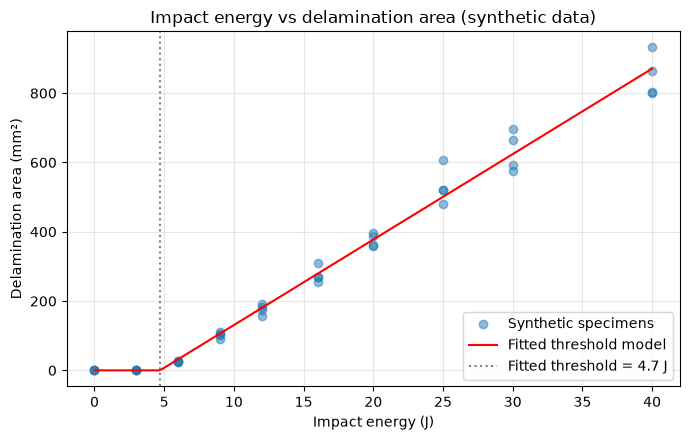

In [5]:
Es = np.linspace(0, 40, 200)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(E, A, alpha=0.5, label="Synthetic specimens")
ax.plot(Es, delamination_area(Es, *popt_area), "r-", label="Fitted threshold model")
ax.axvline(popt_area[0], color="grey", linestyle=":", label=f"Fitted threshold = {popt_area[0]:.1f} J")
ax.set_xlabel("Impact energy (J)")
ax.set_ylabel("Delamination area (mm²)")
ax.set_title("Impact energy vs delamination area (synthetic data)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/damage_vs_energy.png", dpi=300)
plt.show()

In [6]:
popt_str, pcov_str = curve_fit(residual_strength, A, S, p0=[400.0, 0.003, 0.5])
report(["sigma0", "beta", "r"], popt_str, pcov_str, len(A), TRUE)

sigma0  =  453.4301   95% CI [ 448.0356,  458.8245]   true = 450.0   recovered: True
beta    =    0.0042   95% CI [   0.0038,    0.0046]   true = 0.004   recovered: True
r       =    0.4496   95% CI [   0.4311,    0.4681]   true = 0.45   recovered: True


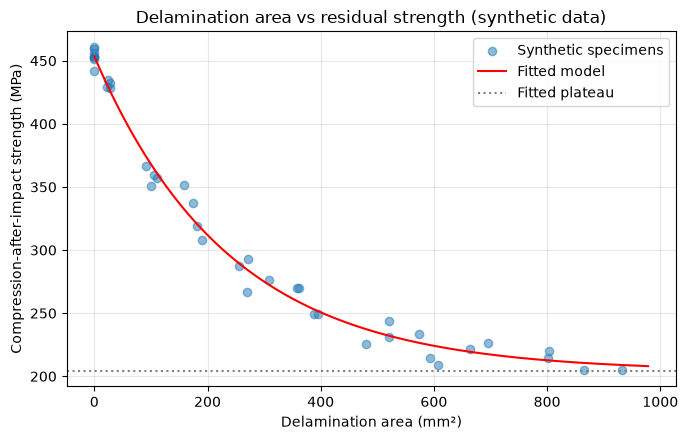

In [7]:
As = np.linspace(0, A.max() * 1.05, 200)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(A, S, alpha=0.5, label="Synthetic specimens")
ax.plot(As, residual_strength(As, *popt_str), "r-", label="Fitted model")
ax.axhline(popt_str[0] * popt_str[2], color="grey", linestyle=":", label="Fitted plateau")
ax.set_xlabel("Delamination area (mm²)")
ax.set_ylabel("Compression-after-impact strength (MPa)")
ax.set_title("Delamination area vs residual strength (synthetic data)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/strength_vs_area.png", dpi=300)
plt.show()

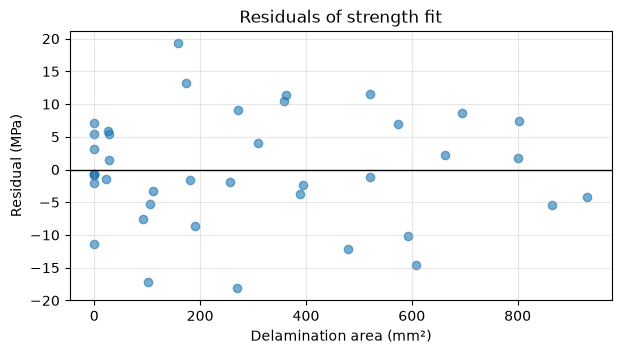

Residual standard deviation: 8.7 MPa


In [8]:
residuals = S - residual_strength(A, *popt_str)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(A, residuals, alpha=0.6)
ax.axhline(0, color="k", linewidth=1)
ax.set_xlabel("Delamination area (mm²)")
ax.set_ylabel("Residual (MPa)")
ax.set_title("Residuals of strength fit")
ax.grid(alpha=0.3)
plt.show()

print(f"Residual standard deviation: {residuals.std(ddof=3):.1f} MPa")

In [9]:
E_th, c = popt_area
sigma0, beta, r = popt_str

S_chain = predict_strength_from_energy(E, E_th, c, sigma0, beta, r)

lin = stats.linregress(E, S)
S_lin = lin.intercept + lin.slope * E

def r_squared(y, y_hat):
    return 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)

def rmse(y, y_hat):
    return np.sqrt(np.mean((y - y_hat) ** 2))

print(f"Physics-based chain: R² = {r_squared(S, S_chain):.3f}, RMSE = {rmse(S, S_chain):.1f} MPa")
print(f"Straight line:       R² = {r_squared(S, S_lin):.3f}, RMSE = {rmse(S, S_lin):.1f} MPa")

Physics-based chain: R² = 0.987, RMSE = 10.4 MPa
Straight line:       R² = 0.858, RMSE = 34.8 MPa


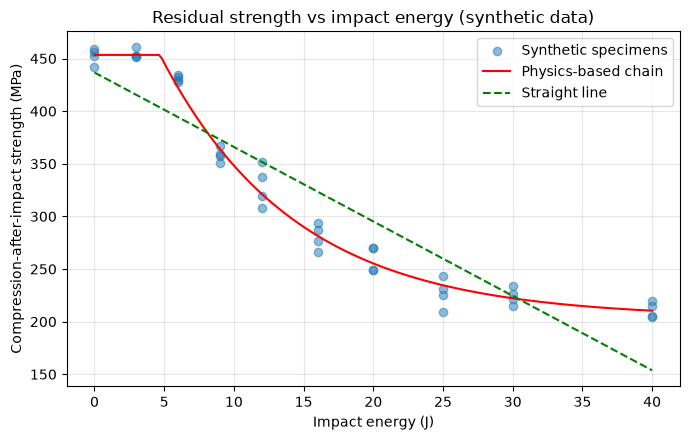

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(E, S, alpha=0.5, label="Synthetic specimens")
ax.plot(Es, predict_strength_from_energy(Es, E_th, c, sigma0, beta, r), "r-", label="Physics-based chain")
ax.plot(Es, lin.intercept + lin.slope * Es, "g--", label="Straight line")
ax.set_xlabel("Impact energy (J)")
ax.set_ylabel("Compression-after-impact strength (MPa)")
ax.set_title("Residual strength vs impact energy (synthetic data)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/chain_prediction.png", dpi=300)
plt.show()